In [2]:
import os
from sklearn.linear_model import ElasticNetCV
import pycountry
print(os.path.getsize("bq-results-20260301-191650-1772410642580"))

15552002


In [3]:
import pandas as pd

df = pd.read_parquet("bq-results-20260301-191650-1772410642580")

# Convert DATE column
df['DATE'] = pd.to_datetime(df['DATE'], format='%Y%m%d%H%M%S')

# Filter between 2018–2024 (inclusive)
df = df[(df['DATE'] >= '2018-01-01') & (df['DATE'] <= '2024-12-31')]

print("After time filter:", df.shape)


After time filter: (5000, 6)


In [4]:
print(df.shape)
print(df.columns)
df.head()

(5000, 6)
Index(['DATE', 'SourceCommonName', 'DocumentIdentifier', 'V2Themes',
       'V2Locations', 'V2Tone'],
      dtype='object')


,DATE,SourceCommonName,DocumentIdentifier,V2Themes,V2Locations,V2Tone
0,2024-01-17 15:45:00,thefrontierpost.com,https://thefrontierpost.com/lack-of-snow-spark...,"TAX_RELIGION_ISLAM,2190;EPU_CATS_REGULATION,49...",1#Afghan#AF#AF##33#66#AF#2589;1#Afghan#AF#AF##...,"-2.8006589785832,0.658978583196046,3.459637561..."
1,2024-01-17 15:45:00,thisdaylive.com,https://www.thisdaylive.com:443/index.php/2024...,"EPU_ECONOMY,704;EPU_ECONOMY_HISTORIC,704;TAX_E...","4#Kebbi, Sokoto, Nigeria#NI#NI51#191023#12.128...","2.66666666666667,4.2962962962963,1.62962962962..."
2,2024-01-17 15:45:00,thisdaylive.com,https://www.thisdaylive.com:443/index.php/2024...,"FOOD_SECURITY,1249;FOOD_SECURITY,3886;WB_199_F...","4#Sokoto, Sokoto, Nigeria#NI#NI51#190962#13.06...","-1.2779552715655,2.31629392971246,3.5942492012..."
3,2024-01-17 15:45:00,thisdaylive.com,https://www.thisdaylive.com:443/index.php/2024...,"CRISISLEX_CRISISLEXREC,1138;EPU_CATS_MIGRATION...",1#New Zealand#NZ#NZ##-42#174#NZ#4719;1#Chile#C...,"0.69848661233993,3.9580908032596,3.25960419091..."
4,2024-01-17 15:45:00,thisdaylive.com,https://www.thisdaylive.com:443/index.php/2024...,"TAX_FNCACT_MINISTERS,4337;TAX_FNCACT_MINISTERS...","4#Edun, Nigeria (General), Nigeria#NI#NI00#191...","2.7060270602706,3.1980319803198,0.492004920049..."


In [5]:
df["DATE"] = pd.to_datetime(df["DATE"], format="%Y%m%d%H%M%S")
df["ToneScore"] = df["V2Tone"].str.split(",").str[0].astype(float)
df["Country"] = df["V2Locations"].str.split("#").str[1]
df = df.dropna(subset=["Country"])
df = df.drop_duplicates(subset="DocumentIdentifier")
df_clean = df[[
    "DATE",
    "SourceCommonName",
    "Country",
    "ToneScore"
]]
df_clean.to_csv("gdelt_cleaned.csv", index=False)

In [6]:
import pandas as pd 
df = pd.read_csv("gdelt_cleaned.csv")
df.head()

,DATE,SourceCommonName,Country,ToneScore
0,2024-01-17 15:45:00,thefrontierpost.com,Afghan,-2.800659
1,2024-01-17 15:45:00,thisdaylive.com,"Kebbi, Sokoto, Nigeria",2.666667
2,2024-01-17 15:45:00,thisdaylive.com,"Sokoto, Sokoto, Nigeria",-1.277955
3,2024-01-17 15:45:00,thisdaylive.com,New Zealand,0.698487
4,2024-01-17 15:45:00,thisdaylive.com,"Edun, Nigeria (General), Nigeria",2.706027


In [7]:
print(df.shape)
print(df.columns)
df["Country"].value_counts().head(10)

(4343, 4)
Index(['DATE', 'SourceCommonName', 'Country', 'ToneScore'], dtype='object')


Country
China                        138
United States                 92
United Kingdom                88
California, United States     84
Vietnam                       63
Chinese                       55
British                       55
American                      53
Ukraine                       52
Alaska, United States         47
Name: count, dtype: int64

In [8]:
df['DATE'] = df['DATE'].astype(str).str.strip()

In [9]:
df['DATE'] = pd.to_datetime(df['DATE'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

In [10]:
print(df['DATE'].dtype)

datetime64[ns]


In [11]:
df['year'] = df['DATE'].dt.year
df['month'] = df['DATE'].dt.month
df['day_of_week'] = df['DATE'].dt.dayofweek
df['hour'] = df['DATE'].dt.hour

In [12]:
df[['DATE','year','month','hour']].head()

,DATE,year,month,hour
0,2024-01-17 15:45:00,2024,1,15
1,2024-01-17 15:45:00,2024,1,15
2,2024-01-17 15:45:00,2024,1,15
3,2024-01-17 15:45:00,2024,1,15
4,2024-01-17 15:45:00,2024,1,15


In [13]:
df['main_country'] = df['Country'].astype(str).str.split(',').str[-1].str.strip()

In [14]:
df[['Country','main_country']].head()

,Country,main_country
0,Afghan,Afghan
1,"Kebbi, Sokoto, Nigeria",Nigeria
2,"Sokoto, Sokoto, Nigeria",Nigeria
3,New Zealand,New Zealand
4,"Edun, Nigeria (General), Nigeria",Nigeria


In [15]:
region_map = {
    "Nigeria": "Africa",
    "Afghan": "Asia",
    "Afghanistan": "Asia",
    "New Zealand": "Oceania",
    "United States": "North America",
    "China": "Asia",
    "India": "Asia",
    "United Kingdom": "Europe",
    "France": "Europe",
    "Germany": "Europe"
}

In [16]:
df['region'] = df['main_country'].map(region_map)

In [17]:
df['region'] = df['region'].fillna("Other")

In [18]:
df = pd.get_dummies(df, columns=['region'], drop_first=True)

In [19]:
# IMPORTS
import pandas as pd

# LOAD DATA
df = pd.read_parquet("bq-results-20260301-191650-1772410642580")

print("Initial shape:", df.shape)


# CLEAN THEMES
# Remove numeric scores like "CLIMATE_CHANGE,20"
df['V2Themes_clean'] = df['V2Themes'].apply(
    lambda x: ';'.join([t.split(',')[0] for t in str(x).split(';')])
)

# Convert to list
df['themes_list'] = df['V2Themes_clean'].str.split(';')

print("Themes example:", df['themes_list'].head())


# 4. EXTRACT COUNTRY FROM V2Locations
def extract_country(location):
    if pd.isna(location):
        return None
    try:
        first_loc = location.split(';')[0]
        parts = first_loc.split('#')
        return parts[2]  # country code
    except:
        return None

df['Country'] = df['V2Locations'].apply(extract_country)

print("Countries example:", df['Country'].unique()[:10])



# DROP MISSING VALUES
df = df.dropna(subset=['Country', 'themes_list'])

print("After cleaning:", df.shape)



# EXPLODE THEMES
df_expanded = df.explode('themes_list')

print("Expanded shape:", df_expanded.shape)


# GROUP BY COUNTRY + THEME
counting = (
    df_expanded
    .groupby(['Country', 'themes_list'])
    .size()
    .reset_index(name='count')
)

print("Counting sample:")
print(counting.head())


# CREATE FEATURE MATRIX
features = counting.pivot(
    index="Country",
    columns="themes_list",
    values="count"
).fillna(0)

print("Feature matrix shape:", features.shape)

#  NORMALIZE 
features_norm = features.div(features.sum(axis=1), axis=0)

print("Normalized sample:")
print(features_norm.head())

#GET TOP GLOBAL THEMES
top_themes = features.sum().sort_values(ascending=False).head(20)

print("Top themes:")
print(top_themes)


Initial shape: (5000, 6)
Themes example: 0    [TAX_RELIGION_ISLAM, EPU_CATS_REGULATION, TAX_...
1    [EPU_ECONOMY, EPU_ECONOMY_HISTORIC, TAX_ECON_P...
2    [FOOD_SECURITY, FOOD_SECURITY, WB_199_FOOD_SEC...
3    [CRISISLEX_CRISISLEXREC, EPU_CATS_MIGRATION_FE...
4    [TAX_FNCACT_MINISTERS, TAX_FNCACT_MINISTERS, T...
Name: themes_list, dtype: object
Countries example: ['AF' 'NI' 'NZ' 'IN' 'EI' 'US' 'UK' 'GM' 'CH' 'FR']
After cleaning: (4343, 9)
Expanded shape: (384390, 9)
Counting sample:
  Country       themes_list  count
0      AE                       14
1      AE            AFFECT      3
2      AE       AGRICULTURE      3
3      AE  AID_HUMANITARIAN      1
4      AE          ALLIANCE      2
Feature matrix shape: (168, 3978)
Normalized sample:
themes_list            ACT_FORCEPOSTURE  ACT_HARMTHREATEN  ACT_MAKESTATEMENT  \
Country                                                                        
AE           0.011041               0.0               0.0                0.0   
AF    

In [20]:
#Looking for top keywords per country
top_keywords = features_norm.apply(lambda x: x.sort_values(ascending=False).head(5), axis=1)

In [21]:
print(features.shape)
print(features.head())

(168, 3978)
themes_list        ACT_FORCEPOSTURE  ACT_HARMTHREATEN  ACT_MAKESTATEMENT  \
Country                                                                    
AE           14.0               0.0               0.0                0.0   
AF            8.0               0.0               0.0                0.0   
AG            3.0               0.0               0.0                0.0   
AJ            8.0               0.0               0.0                0.0   
AL            5.0               0.0               0.0                0.0   

themes_list  ACT_YIELD  AFFECT  AGRICULTURE  AID_HUMANITARIAN  ALLIANCE  \
Country                                                                   
AE                 0.0     3.0          3.0               1.0       2.0   
AF                 0.0    13.0          2.0               0.0       0.0   
AG                 0.0     1.0          2.0               0.0       0.0   
AJ                 0.0     1.0         15.0               0.0       0.0   
AL   

In [22]:
# Step 1: Create clean tone column
df['Tone'] = df['V2Tone'].apply(
    lambda x: float(str(x).split(',')[0]) if pd.notna(x) else None
)
# =========================
# FIX: CONVERT ISO CODES → FULL COUNTRY NAMES
# =========================

tone_by_country = df.groupby('Country')['Tone'].mean().reset_index()

# AUTO-CONVERT ISO → COUNTRY NAMES

def iso_to_country(code):
    try:
        return pycountry.countries.get(alpha_2=code).name.upper()
    except:
        return code  # leave it if not found

tone_by_country['Country'] = tone_by_country['Country'].apply(iso_to_country)


In [23]:
print("Matching countries:",
      len(set(features_norm['Country']).intersection(set(tone_by_country['Country']))))

KeyError: 'Country'

In [ ]:
model_data = pd.merge(features_norm, tone_by_country, on='Country')

print("Model data shape:", model_data.shape)

In [ ]:
X = model_data.drop(columns=['Tone', 'Country'])
y = model_data['Tone']

# remove non-feature columns
X = X.drop(columns=['level_0', 'index'], errors='ignore')

print("X shape after dropping junk columns:", X.shape)

# VARIANCE FILTER (FIXED)
feature_variance = X.var()

X = X.loc[:, feature_variance > 1e-6]

print("After variance filter:", X.shape)

In [ ]:
# NON-ZERO FILTER
non_zero_counts = (X > 0).sum()

# keep features that appear in at least 5 countries
X = X.loc[:, non_zero_counts >= 5]

print("After non-zero filter:", X.shape)

In [ ]:
# CORRELATION FILTER
import numpy as np

corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

X = X.drop(columns=to_drop)

print("After correlation filter:", X.shape)

In [ ]:
# LASSO FEATURE SELECTION
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

# scale BEFORE lasso
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_scaled, y)

selected_features = X.columns[lasso.coef_ != 0]

print("Selected features after Lasso:", len(selected_features))

# reduce X
X = X[selected_features]

In [ ]:
# FINAL MODEL PIPELINE

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.metrics import r2_score

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#LASSO 

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train_scaled, y_train)

selected_features = X.columns[lasso.coef_ != 0]
print("Features after Lasso:", len(selected_features))

# Reduce again
X_train = X_train[selected_features]
X_test = X_test[selected_features]

# Re-scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# FINAL LINEAR REGRESSION
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)

print("Final R²:", r2)

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Tone")
plt.ylabel("Predicted Tone")
plt.title("Model Performance: Predicted vs Actual Tone")

# add diagonal reference line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])



In [ ]:
import seaborn as sns 

In [ ]:
pip install pycountry 

In [ ]:
pip install plotly 

In [ ]:
import plotly.io as pio
pio.renderers.default = "browser"

import plotly.io as pio
pio.renderers.default = "browser"

fig = px.choropleth(
    df_map,
    locations="iso3",
    color="Tone",
    color_continuous_scale="RdBu",
    title="Global Variation in Climate News Tone"
    
)
fig.update_layout(
    title=dict(
        text="Global Variation in Climate News Tone",
        x=0.5,          # center it
        xanchor='center',
        y=0.85          # move it DOWN closer to map
    ),
    margin=dict(t=50)   # reduce top space (default is ~100+)
)

fig.show()

In [ ]:
top_themes = features.sum().sort_values(ascending=False).head(10)

top_themes.plot(kind='bar')
plt.title("Top Climate Themes Globally")
plt.xlabel("Theme")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# load image mask
mask = np.array(Image.open("world_map.png"))

# prepare text
text = " ".join(df_expanded['themes_list'].dropna())

# create word cloud
wc = WordCloud(
    width=1000,
    height=600,
    background_color='white',
    colormap='viridis',
    mask=mask,
    contour_width=1,
    contour_color='black'
).generate(text)

# plot
plt.figure(figsize=(10,6))
plt.imshow(wc)
plt.axis("off")
plt.title("Global Climate Themes", fontsize=16)
plt.show()

In [ ]:
pip install pycountry_convert

In [ ]:
print(df_expanded['Region'].isna().sum())
print(len(df_expanded))

In [ ]:
df = df.loc[:, ~df.columns.duplicated()]

print(df.columns)

In [ ]:
# find correct tone column automatically
tone_col = 'Tone' if 'Tone' in df.columns else 'V2Tone'

# fix tone values (extract first number)
df['Tone_clean'] = df[tone_col].astype(str).str.split(',').str[0]

# convert to numeric
df['Tone_clean'] = pd.to_numeric(df['Tone_clean'], errors='coerce')

import matplotlib.pyplot as plt

# =========================
# FIX DUPLICATES
# =========================
df = df.loc[:, ~df.columns.duplicated()]

# =========================
# FIX TONE
# =========================
tone_col = 'Tone' if 'Tone' in df.columns else 'V2Tone'

df['Tone_clean'] = df[tone_col].astype(str).str.split(',').str[0]
df['Tone_clean'] = pd.to_numeric(df['Tone_clean'], errors='coerce')

# =========================
# CREATE THEMES
# =========================
df['themes_list'] = df['V2Themes'].astype(str).str.split(';')

df_expanded = df.explode('themes_list')

# =========================
# CLEAN
# =========================
df_expanded = df_expanded.dropna(subset=['themes_list', 'Tone_clean'])

df_expanded['themes_list'] = df_expanded['themes_list'].str.strip()

df_expanded = df_expanded[
    (df_expanded['themes_list'] != "") &
    (df_expanded['themes_list'] != "nan")
]

# =========================
# GROUP + MEAN
# =========================
keyword_tone = (
    df_expanded
    .groupby('themes_list')['Tone_clean']
    .mean()
)

# keep top themes
top_themes = df_expanded['themes_list'].value_counts().head(12).index
keyword_tone = keyword_tone.loc[top_themes].sort_values()

# =========================
# PLOT
# =========================
plt.figure(figsize=(8,6))
plt.barh(keyword_tone.index, keyword_tone.values)

plt.title("Average Tone by Climate Theme")
plt.xlabel("Average Tone")
plt.axvline(0)

plt.tight_layout()
plt.show()

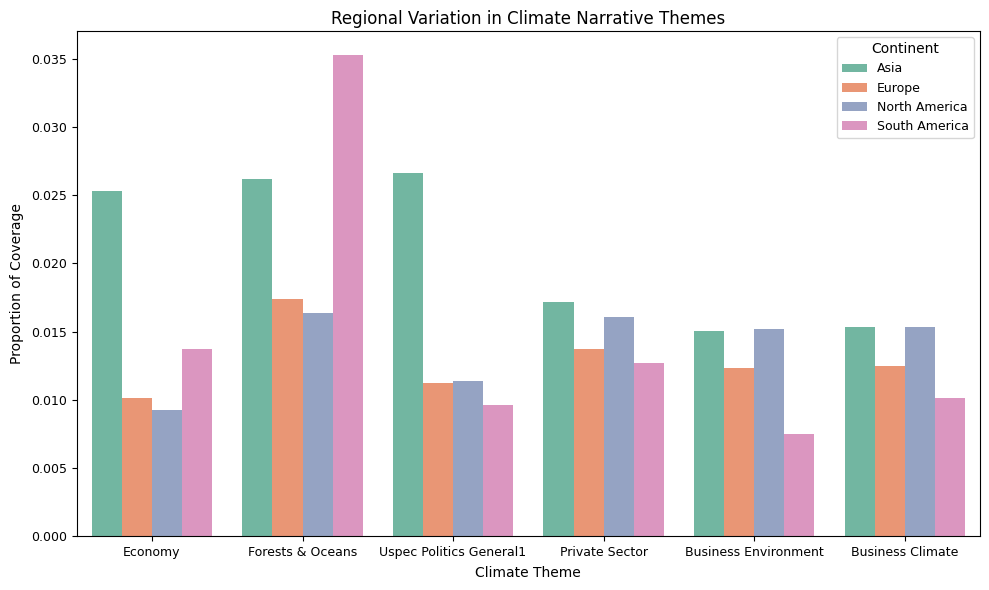

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# STEP 1: Group data
# =========================
theme_counts = df_expanded.groupby(['Continent', 'themes_list']).size().reset_index(name='count')

# =========================
# STEP 2: Select top themes
# =========================
top_themes = (
    theme_counts.groupby('themes_list')['count']
    .sum()
    .nlargest(6)
    .index
)

# =========================
# STEP 3: Normalize (THIS IS KEY)
# =========================
theme_counts['percent'] = theme_counts.groupby('Continent')['count'].transform(lambda x: x / x.sum())

# =========================
# STEP 4: Filter AFTER normalization
# =========================
filtered = theme_counts[theme_counts['themes_list'].isin(top_themes)].copy()

# =========================
# STEP 5: Clean labels
# =========================
filtered['themes_clean'] = (
    filtered['themes_list']
    .str.replace('_', ' ')
    .str.title()
)

# Optional: shorten long labels (highly recommended)
label_map = {
    'Ungp Forests Rivers Oceans': 'Forests & Oceans',
    'Epu Economy Historic': 'Economy',
    'Wb 2530 Business Environment': 'Business Environment',
    'Wb 1921 Private Sector Development': 'Private Sector',
    'Usbic Politics General1': 'Politics',
    'Wb 405 Business Climate': 'Business Climate'
}

filtered['themes_clean'] = filtered['themes_clean'].replace(label_map)

# STEP 6: Plot

plt.figure(figsize=(10,6))

sns.barplot(
    data=filtered,
    x='themes_clean',
    y='percent',
    hue='Continent',
    palette='Set2'
)

# 🔧 FIX LABELS (not slanted + smaller)
plt.xticks(rotation=0, fontsize=9)
plt.yticks(fontsize=9)

# 🔧 TIGHT TITLE SPACING
plt.title("Regional Variation in Climate Narrative Themes", fontsize=12, pad=5)

# 🔧 AXIS LABELS (clean + smaller)
plt.xlabel("Climate Theme", fontsize=10, labelpad=5)
plt.ylabel("Proportion of Coverage", fontsize=10, labelpad=5)

# 🔧 LEGEND
plt.legend(title="Continent", fontsize=9, title_fontsize=10)

plt.tight_layout()
plt.show()

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


NameError: name 'X' is not defined

In [50]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.7)

plt.axhline(0, linestyle='--')
plt.xlabel("Predicted Tone")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot: Model Error Analysis")

plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'y_test' is not defined